# Using `reduce_dimensions` to Visualize Inference Output

Dimensionality-reduction algorithms can project high-dimensional data into a lower-dimensional space while preserving important structure in the data. This can make it easier to visualize and explore latent representations learned by machine learning models.

In this notebook, we will primarily use [UMAP](https://umap-learn.readthedocs.io) (Uniform Manifold Approximation and Projection), a dimensionality reduction algorithm that is particularly effective at preserving local relationships between data. This makes it ideal for visualizing the latent space learned by an unsupervised model.

Hyrax provides a `reduce_dimensions` verb for applying dimensionality reduction to inference outputs. Multiple algorithms are supported, including [UMAP](https://umap-learn.readthedocs.io), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (T-distributed Stochastic Neighbor Embedding), and [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) (Principal Component Analysis).
The desired algorithm can be selected through the `algorithm` argument or configuration.
Throughout most of this notebook we will use UMAP, then briefly demonstrate how the same workflow can be applied using other supported algorithms.

<!-- [UMAP](https://umap-learn.readthedocs.io) (Uniform Manifold Approximation and Projection) is a
dimensionality-reduction algorithm that projects high-dimensional data into 2 or 3 dimensions
while preserving local structure. This makes it ideal for visualizing the latent
space learned by an unsupervised model. -->

In this notebook we will:

1. Train a simple autoencoder on random data.
2. Run inference to obtain latent-space representations.
3. Apply `reduce_dimensions` with UMAP to produce a **2D** embedding.
4. Load and plot the reduced-dimensional output.
5. Show how to switch to **3D** output.
6. Show how to load a previously saved UMAP model.
7. Show how to run the same workflow using t-SNE and PCA.

## 1. Setup

Create a Hyrax instance and configure it to use the built-in
``HyraxAutoencoder`` model with the ``HyraxRandomDataset``.
The random dataset lets us run the full pipeline quickly without
downloading real data.

In [1]:
from hyrax import Hyrax
from hyrax.config_utils import find_most_recent_results_dir

h = Hyrax()

In [2]:
# Use an autoencoder (unsupervised) so inference produces a latent vector.
h.set_config("model.name", "HyraxAutoencoder")

# Point at the random dataset — no download required.
data_request = {
    "train": {
        "data": {
            "dataset_class": "HyraxRandomDataset",
            "data_location": ".",
            "fields": ["image"],
            "primary_id_field": "object_id",
        },
    },
    "infer": {
        "data": {
            "dataset_class": "HyraxRandomDataset",
            "data_location": ".",
            "fields": ["image"],
            "primary_id_field": "object_id",
        },
    },
}
h.set_config("data_request", data_request)

# Train for just 1 epoch to keep things fast.
h.set_config("train.epochs", 1)

## 2. Train and Infer

Train the autoencoder and then run inference to produce
latent-space representations for every item in the dataset.

In [ ]:
model = h.train()
inference_results = h.infer()

## 3. Run UMAP (2D)

By default Hyrax reduces to **2 components** (``n_components = 2``).
Calling ``h.reduce_dimensions(algorithm="umap")`` fits a UMAP model on a sample of the inference
output, then transforms the entire dataset. 
If the `algorithm` argument is omitted, `reduce_dimensions` uses the default algorithm specified in the configuration (UMAP by default).

In [4]:
umap_results = h.reduce_dimensions(algorithm="umap")

[2026-06-25 14:51:26,940 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145126-umap-jcVH
[2026-06-25 14:51:26,944 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-06-25 14:51:26,944 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-06-25 14:51:30,642 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:31,871 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:31,873 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:31,874 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


``h.reduce_dimensions()`` returns a ``ResultDataset`` that you can index directly.
Each element is a NumPy array with shape ``(,n_components)``.

In [5]:
import numpy as np

# Stack all UMAP embeddings into a single array.
umap_embeddings = np.array([umap_results[i] for i in range(len(umap_results))])
print(f"Shape: {umap_embeddings.shape}  (samples × components)")

Shape: (100, 2)  (samples × components)


## 4. Plot the 2D Embedding

A quick scatter plot of the two UMAP dimensions.

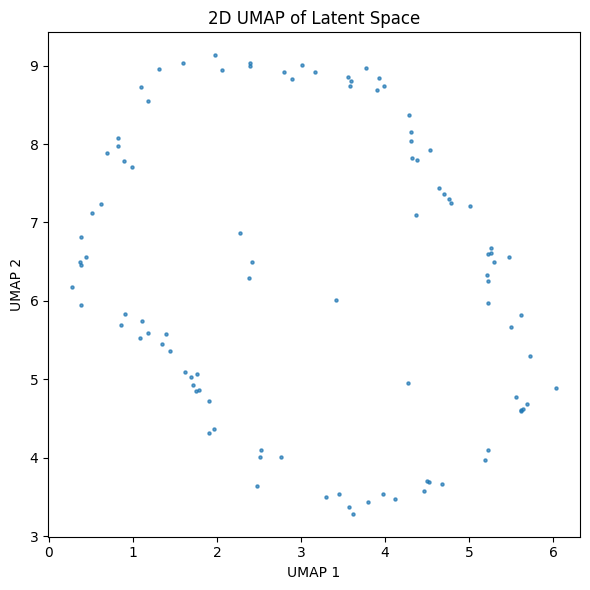

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], s=5, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("2D UMAP of Latent Space")
plt.tight_layout()
plt.show()

## 5. Switch to 3D

To produce a 3-dimensional embedding instead, set
``n_components`` to 3 before calling ``h.reduce_dimensions()`` again.

In [7]:
h.set_config("reduce.umap.kwargs.n_components", 3)
umap_results_3d = h.reduce_dimensions(algorithm="umap")

# save the path for loading the model
result_dir_3d = find_most_recent_results_dir(h.config, "umap")

[2026-06-25 14:51:32,100 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-MWlb
[2026-06-25 14:51:32,103 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-06-25 14:51:32,103 hyrax.verbs.reduction_algorithms.umap:INFO] Fitting the UMAP
[2026-06-25 14:51:32,159 hyrax.verbs.reduce_dimensions:INFO] Saving fitted umap reducer to result directory


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:32,335 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:32,337 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:32,337 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


Shape: (100, 3)  (samples × components)


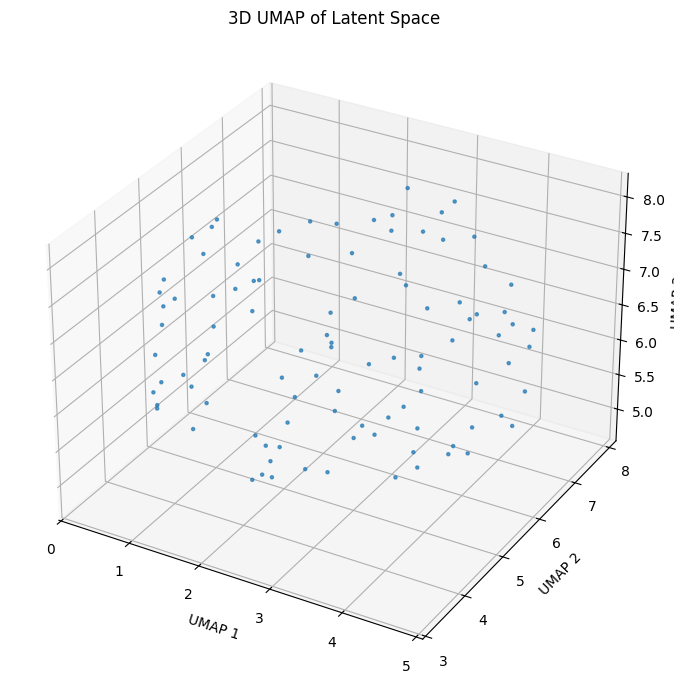

In [8]:
umap_embeddings_3d = np.array([umap_results_3d[i] for i in range(len(umap_results_3d))])
print(f"Shape: {umap_embeddings_3d.shape}  (samples × components)")

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(umap_embeddings_3d[:, 0], umap_embeddings_3d[:, 1], umap_embeddings_3d[:, 2], s=5, alpha=0.7)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_zlabel("UMAP 3")
ax.set_title("3D UMAP of Latent Space")
plt.tight_layout()
plt.show()

## 6. Loading Previously Saved UMAP Model

When running the `reduce_dimensions` verb with the UMAP algorithm, the fitted reducer can be saved to the results directory as *./umap.pickle* if enabled in the configuration. We can reuse a previously trained UMAP reducer model to ensure consistent results and faster workflow.

To do this, pass the saved model path via the `model_path` argument:

In [9]:
umap_results_load = h.reduce_dimensions(algorithm="umap", model_path=result_dir_3d / "umap.pickle")

[2026-06-25 14:51:32,423 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-dF_K
[2026-06-25 14:51:32,426 hyrax.verbs.reduce_dimensions:INFO] Loading pre-existing reducer model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-MWlb/umap.pickle
[2026-06-25 14:51:32,427 hyrax.verbs.reduction_algorithms.umap:INFO] Loading pre-existing UMAP model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-MWlb/umap.pickle


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:32,621 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:32,623 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:32,623 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


The resulting shape should be the same as the 3D result. 

In [10]:
# Stack all UMAP embeddings into a single array.
umap_embeddings_3d_load = np.array([umap_results_load[i] for i in range(len(umap_results_load))])
print(f"Shape: {umap_embeddings_3d_load.shape}  (samples × components)")

Shape: (100, 3)  (samples × components)


It is also possible to specify a `model_path` for UMAP model directly in the configuration. If it is set, running the `reduce_dimensions` verb will automatically load and use the previously saved reducer.

This allows us to reuse a saved model without passing the path explicitly each time.

In [11]:
# set the model_path in config
h.set_config("reduce.umap.model_path", str(result_dir_3d / "umap.pickle"))
umap_results_load_config = h.reduce_dimensions(algorithm="umap")

# Stack all UMAP embeddings into a single array.
umap_embeddings_3d_load_config = np.array(
    [umap_results_load_config[i] for i in range(len(umap_results_load_config))]
)
print(f"Shape: {umap_embeddings_3d_load_config.shape}  (samples × components)")

[2026-06-25 14:51:32,677 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using umap to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-ItqV
[2026-06-25 14:51:32,679 hyrax.verbs.reduce_dimensions:INFO] Loading pre-existing reducer model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-MWlb/umap.pickle
[2026-06-25 14:51:32,679 hyrax.verbs.reduction_algorithms.umap:INFO] Loading pre-existing UMAP model from /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-umap-MWlb/umap.pickle


Creating lower dimensional representation using UMAP::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:32,845 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:32,847 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:32,847 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with umap


Shape: (100, 3)  (samples × components)


Basic checks (e.g., file validity and dimensions compatibility) are handled automatically, but it is important to check that the provided model is meaningful for current dataset and task.

**Note:** This workflow is only available for dimensionality-reduction algorithms that first learn a tranformation and then apply that transformation to the entire dataset. UMAP and PCA support this pattern, allowing Hyrax to fit a reducer on a sample data and then transform the full dataset using the learned mapping. If enabled, the fitted model is saved in the results directory as *./\<algorithm\>.pickle*.
In contrast, t-SNE directly optimizes the low-dimensional positions of the data points rather than learning a reusable mapping. Because of this, it's not appicable to save and reuse a t-SNE reducer for new data.

## 7. Using Other Reduction Algorithm

The same `reduce_dimensions` workflow can be applied to other supported algorithms by simply changing the `algorithm` argument, i.e. `h.reduce_dimensions(algorithm="<name>")`. Currently, `reduce_dimensions` supports two additinal dimensionality-reduction algorithms: pca and tsne. 

2D results with other reduction algorithms for the random dataset are as follow:

In [12]:
tsne_results = h.reduce_dimensions(algorithm="tsne")

[2026-06-25 14:51:32,888 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using tsne to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145132-tsne-JtxA
[2026-06-25 14:51:32,890 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-06-25 14:51:32,891 hyrax.verbs.reduction_algorithms.tsne:WARNING] TSNE does not support a separate fitting stage. Skipping fit.
[2026-06-25 14:51:32,891 hyrax.verbs.reduce_dimensions:INFO] Saving fitted tsne reducer to result directory
[2026-06-25 14:51:32,891 hyrax.verbs.reduction_algorithms.tsne:WARNING] TSNE does not support saving the model. Skipping save_model.


Creating lower dimensional representation using t-SNE::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:33,264 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:33,267 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:33,267 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with tsne


Shape: (100, 2)  (samples × components)


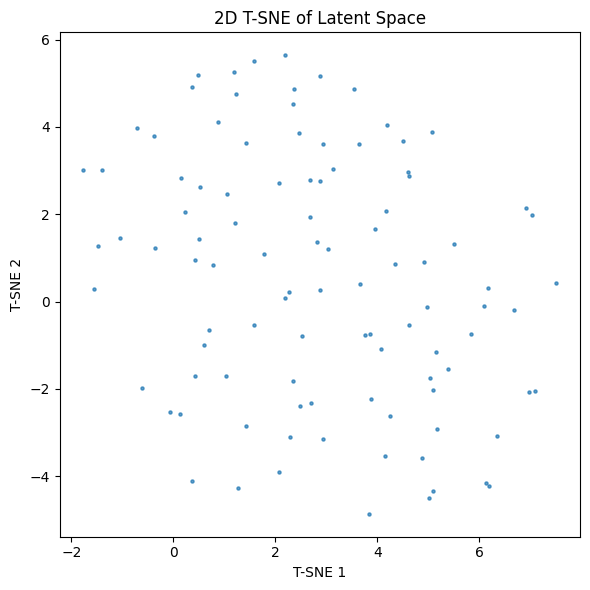

In [13]:
# Stack all T-SNE embeddings into a single array.
tsne_embeddings = np.array([tsne_results[i] for i in range(len(tsne_results))])
print(f"Shape: {tsne_embeddings.shape}  (samples × components)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], s=5, alpha=0.7)
ax.set_xlabel("T-SNE 1")
ax.set_ylabel("T-SNE 2")
ax.set_title("2D T-SNE of Latent Space")
plt.tight_layout()
plt.show()

In [14]:
pca_results = h.reduce_dimensions(algorithm="pca")

[2026-06-25 14:51:33,382 hyrax.verbs.reduce_dimensions:INFO] Saving reduction results using pca to /Users/qiyuwang/Desktop/hyrax/docs/pre_executed/results/20260625-145133-pca-Visw
[2026-06-25 14:51:33,386 hyrax.verbs.reduce_dimensions:INFO] No model_path specified. A new model will be fitted.
[2026-06-25 14:51:33,386 hyrax.verbs.reduction_algorithms.pca:INFO] Fitting the PCA
[2026-06-25 14:51:33,388 hyrax.verbs.reduce_dimensions:INFO] Saving fitted pca reducer to result directory


Creating lower dimensional representation using PCA::   0%|          | 0/1 [00:00<?, ?it/s]

[2026-06-25 14:51:33,573 hyrax.datasets.result_dataset:INFO] Optimizing Lance table after 1 batches
[2026-06-25 14:51:33,575 hyrax.datasets.result_dataset:INFO] Lance table optimization complete
[2026-06-25 14:51:33,575 hyrax.verbs.reduce_dimensions:INFO] Finished transforming all data with pca


Shape: (100, 2)  (samples × components)


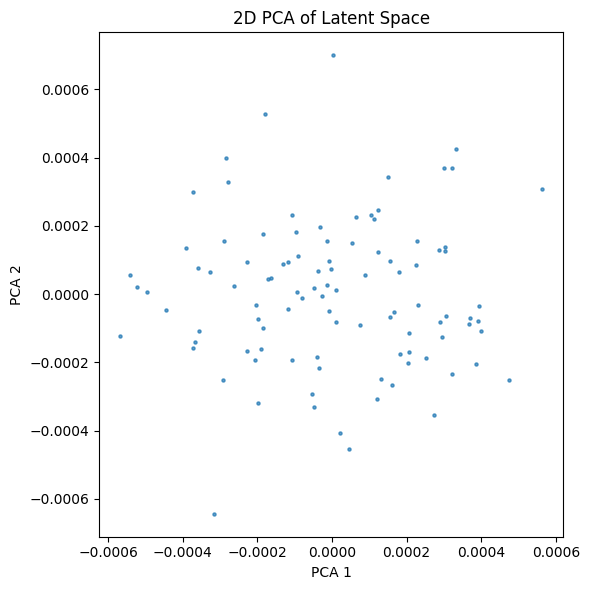

In [15]:
# Stack all PCA embeddings into a single array.
pca_embeddings = np.array([pca_results[i] for i in range(len(pca_results))])
print(f"Shape: {pca_embeddings.shape}  (samples × components)")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], s=5, alpha=0.7)
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_title("2D PCA of Latent Space")
plt.tight_layout()
plt.show()

## Key Configuration Options

All `reduce_dimensions` settings live under the ``[reduce]`` section of the Hyrax config.
The most ocmmonly adjusted parameters are:

### Global settings
| Config key | Default | Description |
|---|---|---|
| ``reduce.algorithm`` | "umap" | Name of the reduction algorithm to use. |
| ``reduce.save_fit_model`` | true | Save the fitted reducer model. |
| ``reduce.parallel`` | false | Use multiprocessing during the transform step. |


### Algorithm-specific configuration
Each algorithm has its own sub-section under ``[reduce.<algorithm>]``.

#### UMAP
| Config key | Default | Description |
|---|---|---|
| ``reduce.umap.kwargs.n_components`` | 2 | Number of output dimensions (2 or 3). |
| ``reduce.umap.kwargs.n_neighbors`` | 15 | Balances local vs. global structure. |
| ``reduce.umap.fit_sample_size`` | 1024 | Number of points used to fit the UMAP model. |
| ``reduce.umap.model_path`` | false | Path to a previously saved UMAP reducer model. |

See the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/parameters.html)
for the full list of parameters you can pass under ``reduce.umap.kwargs``.

#### t-SNE
| Config key | Default | Description |
|---|---|---|
| ``reduce.tsne.kwargs.n_components`` | 2 | Number of output dimensions (2 or 3). |
| ``reduce.tsne.kwargs.perplexity`` | 30.0 | Number of nearest neighbors considered. |

See the [TSNE documentation](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)
for the full list of parameters you can pass under ``reduce.tsne.kwargs``.

#### PCA
| Config key | Default | Description |
|---|---|---|
| ``reduce.pca.kwargs.n_components`` | 2 | Number of output dimensions (2 or 3). |
| ``reduce.pca.fit_sample_size`` | 1024 | Number of points used to fit the PCA model. |
| ``reduce.pca.model_path`` | false | Path to a previously saved PCA reducer model. |

See the [PCA documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
for the full list of parameters you can pass under ``reduce.pca.kwargs``.